# Inference and Testing Model

## Model Overview

| Property | Detail |
|---|---|
| **Base Architecture** | `bert-base-uncased` (12 transformer layers, 110M parameters) |
| **Task** | Binary Sequence Classification |
| **Labels** | `0 = Human-written`, `1 = AI-generated` |
| **Max Token Length** | 300 tokens |
| **Training Epochs** | 3 |
| **Learning Rate** | 2e-5 |
| **Training Data Size** | ~44,552 samples |
| **Saved Location** | `./bert_ai_human_detector/` |

## Requirements if not already installed

In [ ]:
!pip install transformers torch pandas numpy matplotlib seaborn scikit-learn nltk tqdm

## Importing required libraries

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import string
import re
import os
from tqdm import tqdm

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

f:\minor project\.venvprj\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

## Auto detect device (CUDA GPU, MPU, CPU)

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"{torch.cuda.get_device_name(0)} found.")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Apple Silicon MPS GPU found.")
else:
    device = torch.device("cpu")
    print("No GPU found. Defaulting to CPU usage which will be slower.")

No GPU found. Defaulting to CPU usage which will be slower.


## Loading model

In [3]:
path_of_model = "../bert_ai_human_detector"

print("Files:", os.listdir(path_of_model))

Files: ['config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin']


In [4]:
# Loading tokenizer that converts texts to BERT understandable ID
tokenizer = AutoTokenizer.from_pretrained(path_of_model)

In [5]:
model = AutoModelForSequenceClassification.from_pretrained(path_of_model)
model.to(device)       # Move model to GPU/CPU
model.eval()           # Set to evaluation mode — disables dropout layers

Loading weights: 100%|██████████| 201/201 [00:01<00:00, 118.16it/s, Materializing param=classifier.weight]                                      


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
print(f"Model type: {type(model).__name__}")
print(f"Number of labels: {model.config.num_labels}") # Two labels for AI & Human

Model type: BertForSequenceClassification
Number of labels: 2


## Text Preprocessing


In [3]:
stop_words = set(stopwords.words("english"))

In [4]:
# Same function as in src/training.ipynb
def clean_text(text):
    """
    Cleans the input text by performing several operations:
    - Convert to lowercase to maintain uniformity.
    - Remove punctuation to reduce noise.
    - Remove numbers as they may not contribute to text classification in this context.
    - Strip extra spaces for clean, standardized input.
    - Remove stopwords to focus on the meaningful words.
    
    Parameters:
    text (str): The input text to be cleaned.
    
    Returns:
    str: The cleaned text.
    """
    # Convert text to lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove extra spaces
    text = text.strip()
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in stop_words]
    text = ' '.join(filtered_tokens)
    return text

In [5]:
# testing clean_test

test_str = """The St Scholastica Day riot began in Oxford, England, on 10 February 1355, the feast day of St Scholastica. The disturbance began when two students from the University of Oxford complained about the quality of wine served to them in the Swindlestock Tavern, which stood at the crossroads now known as Carfax, in the centre of the town. The students quarrelled with the taverner; the argument quickly escalated to blows. The inn's customers joined in on both sides, and the resulting mêlée turned into a riot. The violence started by the bar brawl continued over three days, with armed gangs entering the town from the countryside to assist the townspeople. University halls and students' accommodation were raided and the inhabitants murdered; there were some reports of scholars being scalped. Around twenty townsfolk were killed, as were up to sixty-three members of the university.
Violent disagreements between townspeople and students had arisen several times previously, and twelve of the twenty-nine coroners' courts held in Oxford between 1297 and 1322 concerned murders by students. The University of Cambridge was established in 1209 by scholars who left Oxford following the lynching of two students by the town's citizens.
King Edward III sent judges to the town with commissions of oyer and terminer to determine what had gone on and to advise what steps should be taken. He came down on the side of the university authorities, who were given additional powers and responsibilities to the disadvantage of the town's authorities. The town was fined 500 marks[a] and its mayor and bailiffs were sent to the Marshalsea prison in London. John Gynwell, the Bishop of Lincoln, imposed an interdict on the town for one year, which banned all religious practices, including services (except on key feast days), burials and marriages; only baptisms of young children were allowed.
An annual penance was imposed on the town: each year, on St Scholastica's Day, the mayor, bailiffs and sixty townspeople were to attend a Mass at the University Church of St Mary the Virgin for those killed; the town was also made to pay the university an annual fine of one penny for each scholar killed. The practice was dropped in 1825; in 1955—the 600th anniversary of the riots—in an act of conciliation the city's mayor was given an honorary degree, while the university's vice-chancellor was made an honorary freeman of the city. 
"""
print(f"Before: {test_str}\n\n")
print(f"After: {clean_text(test_str)}")

Before: The St Scholastica Day riot began in Oxford, England, on 10 February 1355, the feast day of St Scholastica. The disturbance began when two students from the University of Oxford complained about the quality of wine served to them in the Swindlestock Tavern, which stood at the crossroads now known as Carfax, in the centre of the town. The students quarrelled with the taverner; the argument quickly escalated to blows. The inn's customers joined in on both sides, and the resulting mêlée turned into a riot. The violence started by the bar brawl continued over three days, with armed gangs entering the town from the countryside to assist the townspeople. University halls and students' accommodation were raided and the inhabitants murdered; there were some reports of scholars being scalped. Around twenty townsfolk were killed, as were up to sixty-three members of the university.
Violent disagreements between townspeople and students had arisen several times previously, and twelve of t

## Prediction function

In [8]:
# Label mapping — matches the training labels
# generated=1 → AI-Generated, generated=0 → Human-Written
LABEL_MAP = {0: "Human-Written", 1: "AI-Generated"}
LABEL_COLORS = {"Human-Written": "#2ecc71", "AI-Generated": "#e74c3c"}


def predict(text, verbose=True):
    """
    Predicts whether a single text is AI-generated or Human-written.

    Args:
        text (str): The raw input text to classify
        verbose (bool): If True, prints a formatted result summary

    Returns:
        dict: {
            'label'     : 'Human-Written' or 'AI-Generated',
            'label_id'  : 0 or 1,
            'confidence': float (0.0 to 1.0),
            'probs'     : {'Human-Written': float, 'AI-Generated': float}
        }
    """
    # Step 1: Preprocess text (to make the text same way as in training)
    cleaned = clean_text(text)

    # Step 2: Tokenize — same settings as training (max_length=300, truncation, padding)
    inputs = tokenizer(
        cleaned,
        return_tensors="pt",   # Return PyTorch tensors
        truncation=True,
        padding=True,
        max_length=300
    )

    # Move inputs to the same device as the model
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Step 3: Run inference (no gradient tracking needed for inference)
    with torch.no_grad():
        outputs = model(**inputs)

    # Step 4: Convert raw logits → probabilities using softmax
    # logits shape: (1, 2) → one sample, two classes
    probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]

    # Step 5: Get the predicted class
    pred_id    = int(np.argmax(probs))
    pred_label = LABEL_MAP[pred_id]
    confidence = float(probs[pred_id])

    result = {
        'label'     : pred_label,
        'label_id'  : pred_id,
        'confidence': confidence,
        'probs'     : {
            'Human-Written': float(probs[0]),
            'AI-Generated' : float(probs[1])
        }
    }

    if verbose:
        bar_len = 40
        fill    = int(confidence * bar_len)
        bar     = '█' * fill + '░' * (bar_len - fill)
        result_pred   = "AI WRITTEN" if pred_id == 1 else "HUMAN WRITTEN"
        print(f"\n{result_pred}  Prediction : {pred_label}")
        print(f"   Confidence : [{bar}] {confidence:.1%}")
        print(f"   Human prob : {probs[0]:.4f}")
        print(f"   AI prob    : {probs[1]:.4f}")

    return result


def predict_batch(texts, show_progress=True):
    """
    Predicts labels for a list of texts.

    Args:
        texts (list of str): Input texts
        show_progress (bool): Show a progress bar

    Returns:
        pd.DataFrame: Results with columns [text, label, confidence, human_prob, ai_prob]
    """
    results = []
    iterator = tqdm(texts, desc="Predicting") if show_progress else texts

    for text in iterator:
        res = predict(text, verbose=False)
        results.append({
            'text'        : text[:80] + '...' if len(text) > 80 else text,
            'label'       : res['label'],
            'confidence'  : f"{res['confidence']:.1%}",
            'human_prob'  : round(res['probs']['Human-Written'], 4),
            'ai_prob'     : round(res['probs']['AI-Generated'],  4)
        })

    return pd.DataFrame(results)


## Testing individual texts

In [14]:
# Sample 1
ai_text = """
Artificial intelligence has revolutionized numerous industries by enabling machines 
to perform tasks that previously required human intelligence. Through the application 
of machine learning algorithms and neural networks, AI systems can now analyze vast 
amounts of data, recognize patterns, and make decisions with remarkable accuracy. 
This technological advancement has significant implications for healthcare, finance, 
transportation, and education sectors.
"""

print("=" * 60)
print("TEST 1 — Expected: AI-Generated")
print("=" * 60)
print(f"Text preview: {ai_text.strip()[:100]}...")
result1 = predict(ai_text)

TEST 1 — Expected: AI-Generated
Text preview: Artificial intelligence has revolutionized numerous industries by enabling machines 
to perform task...

AI WRITTEN  Prediction : AI-Generated
   Confidence : [███████████████████████████████████████░] 99.4%
   Human prob : 0.0060
   AI prob    : 0.9940


In [17]:
# Sample 2
human_text = """
 A cow is a domestic animal that can be seen in our homes. It is a four-legged animal that comes in various colours like white, black or brown. It may also have large spots on its body. A cow has two small eyes and ears, a big nose, two sharp horns and a long tail with hair at the end. Cows have strong teeth and a mouth that helps them to graze and feed on grass. They also eat husks and grains and are usually seen lazing around in open fields.

As we have understood what a cow looks like, let us see the differences between its male and female counterparts in this essay on the cow. The male counterpart of the cow, the bull, is mainly used by farmers to plough the agricultural land and draw carts. The young cow is called a calf, and the young female is called a heifer. Generally, cows are seen in herds.

Benefits of Cows

Cows are warm animals and they are used for several purposes by humans. The most valuable thing that a cow gives us is milk.. We also use this milk for making curd, butter, ghee and cheese.

In this essay on cows for kids, we will also see how cows are useful for us in other ways. Apart from giving us milk, cows provide us with cow dung, which is considered to be a great fertiliser for soil and plants. Cow dung is also a major source of fuel and biogas. In these ways, cows are very useful for us.

According to the Hindu religion, cows are given the status of a ‘mother’ and they are respected and worshipped in many parts of the country. Thus, cows have a huge importance in our lives, and we must safeguard them. 
"""

print("=" * 60)
print("TEST 2 — Expected: Human-Written")
print("=" * 60)
print(f"Text preview: {human_text.strip()[:100]}...")
result2 = predict(human_text)

TEST 2 — Expected: Human-Written
Text preview: A cow is a domestic animal that can be seen in our homes. It is a four-legged animal that comes in v...

HUMAN WRITTEN  Prediction : Human-Written
   Confidence : [███████████████████████████████████████░] 100.0%
   Human prob : 1.0000
   AI prob    : 0.0000


## Batch prediction
use `predict_batch()` instead

In [23]:
test_texts = [
    # AI-generated style samples
    """Machine learning (ML), a key branch of artificial intelligence, is transforming cattle farming—often called precision livestock farming (PLF)—by enabling data-driven decisions that improve animal health, productivity, welfare, and sustainability. Farmers and researchers now use ML algorithms to process vast amounts of data from sensors, cameras, wearables, and farm records, turning traditional gut-instinct management into predictive, individualized care for cows.
    One of the most impactful applications is early disease detection. ML models analyze real-time data from collars, ear tags, pedometers, and cameras to spot subtle changes in behavior or physiology before visible symptoms appear. For instance, algorithms detect lameness by examining gait patterns in video footage, identify mastitis through udder images, temperature shifts, or milk conductivity, and flag heat stress via activity and breathing changes. Systems like CattleEye use deep learning on AWS cloud platforms to monitor walking patterns and predict lameness risks weeks in advance, reducing treatment costs and antibiotic use. Computer vision models (e.g., YOLO, ResNet, Faster R-CNN) automatically score body condition, estimate weight, or recognize facial cues like nasal discharge for respiratory issues.
    In reproduction and estrus detection, ML optimizes breeding timing by tracking activity spikes, rumination drops, or mounting behavior via sensors. Predictive models forecast calving onset to minimize stillbirth risks and improve insemination success rates.
    Productivity and breeding benefit from ML's ability to predict milk yield, analyze genetic-environmental interactions, and select superior animals. Random Forest and neural networks process nutritional, health, and historical data for precise feed formulation and herd classification (e.g., dairy vs. beef types using national datasets for targeted surveillance).
    Identification and monitoring rely on ML for non-invasive tracking: muzzle patterns, coat markings, or facial recognition replace traditional tags, aiding biosecurity and theft prevention. In beef cattle, similar tools monitor grazing patterns and health in open environments.
    Recent advancements (2024–2025) emphasize multimodal AI—combining vision, sound, temperature, and movement—for more accurate predictions, often with edge computing for real-time farm-level insights and federated learning for privacy-preserving model improvements.
    These technologies boost efficiency (e.g., 15–20% productivity gains in some operations), cut costs, enhance welfare by reducing stress and pain, and support sustainable practices like lower emissions through optimized feeding. Challenges remain, including data quality, model interpretability, and adoption costs, but ML is rapidly making cattle farming smarter, more humane, and resilient.""",

    # Human-written style samples
    """The St Scholastica Day riot began in Oxford, England, on 10 February 1355, the feast day of St Scholastica. The disturbance began when two students from the University of Oxford complained about the quality of wine served to them in the Swindlestock Tavern, which stood at the crossroads now known as Carfax, in the centre of the town. The students quarrelled with the taverner; the argument quickly escalated to blows. The inn's customers joined in on both sides, and the resulting mêlée turned into a riot. The violence started by the bar brawl continued over three days, with armed gangs entering the town from the countryside to assist the townspeople. University halls and students' accommodation were raided and the inhabitants murdered; there were some reports of scholars being scalped. Around twenty townsfolk were killed, as were up to sixty-three members of the university.

Violent disagreements between townspeople and students had arisen several times previously, and twelve of the twenty-nine coroners' courts held in Oxford between 1297 and 1322 concerned murders by students. The University of Cambridge was established in 1209 by scholars who left Oxford following the lynching of two students by the town's citizens.

King Edward III sent judges to the town with commissions of oyer and terminer to determine what had gone on and to advise what steps should be taken. He came down on the side of the university authorities, who were given additional powers and responsibilities to the disadvantage of the town's authorities. The town was fined 500 marks[a] and its mayor and bailiffs were sent to the Marshalsea prison in London. John Gynwell, the Bishop of Lincoln, imposed an interdict on the town for one year, which banned all religious practices, including services (except on key feast days), burials and marriages; only baptisms of young children were allowed.

An annual penance was imposed on the town: each year, on St Scholastica's Day, the mayor, bailiffs and sixty townspeople were to attend a Mass at the University Church of St Mary the Virgin for those killed; the town was also made to pay the university an annual fine of one penny for each scholar killed. The practice was dropped in 1825; in 1955—the 600th anniversary of the riots—in an act of conciliation the city's mayor was given an honorary degree, while the university's vice-chancellor was made an honorary freeman of the city. 
""",

]

# Run batch prediction
print("Running batch prediction on 8 samples...\n")
results_df = predict_batch(test_texts)

# Display results table
print("\n" + "=" * 60)
print("BATCH PREDICTION RESULTS")
print("=" * 60)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
results_df

Running batch prediction on 8 samples...



Predicting:   0%|          | 0/2 [00:00<?, ?it/s]

Predicting: 100%|██████████| 2/2 [00:08<00:00,  4.24s/it]


BATCH PREDICTION RESULTS


,text,label,confidence,human_prob,ai_prob
0,"Machine learning (ML), a key branch of artificial intell...",AI-Generated,100.0%,0.0000,1.0000
1,"The St Scholastica Day riot began in Oxford, England, on...",Human-Written,99.8%,0.9985,0.0015


In [9]:
print("=" * 60)
print("CUSTOM TEXT PREDICTION")
print("=" * 60)

my_text = input("Paste your text here: ")

print("\nClassifying...")
predict(my_text)

CUSTOM TEXT PREDICTION

Classifying...

HUMAN WRITTEN  Prediction : Human-Written
   Confidence : [███████████████████████████████████████░] 100.0%
   Human prob : 1.0000
   AI prob    : 0.0000


{'label': 'Human-Written',
 'label_id': 0,
 'confidence': 0.9999862909317017,
 'probs': {'Human-Written': 0.9999862909317017,
  'AI-Generated': 1.3755600775766652e-05}}

## Visualizing confidence score

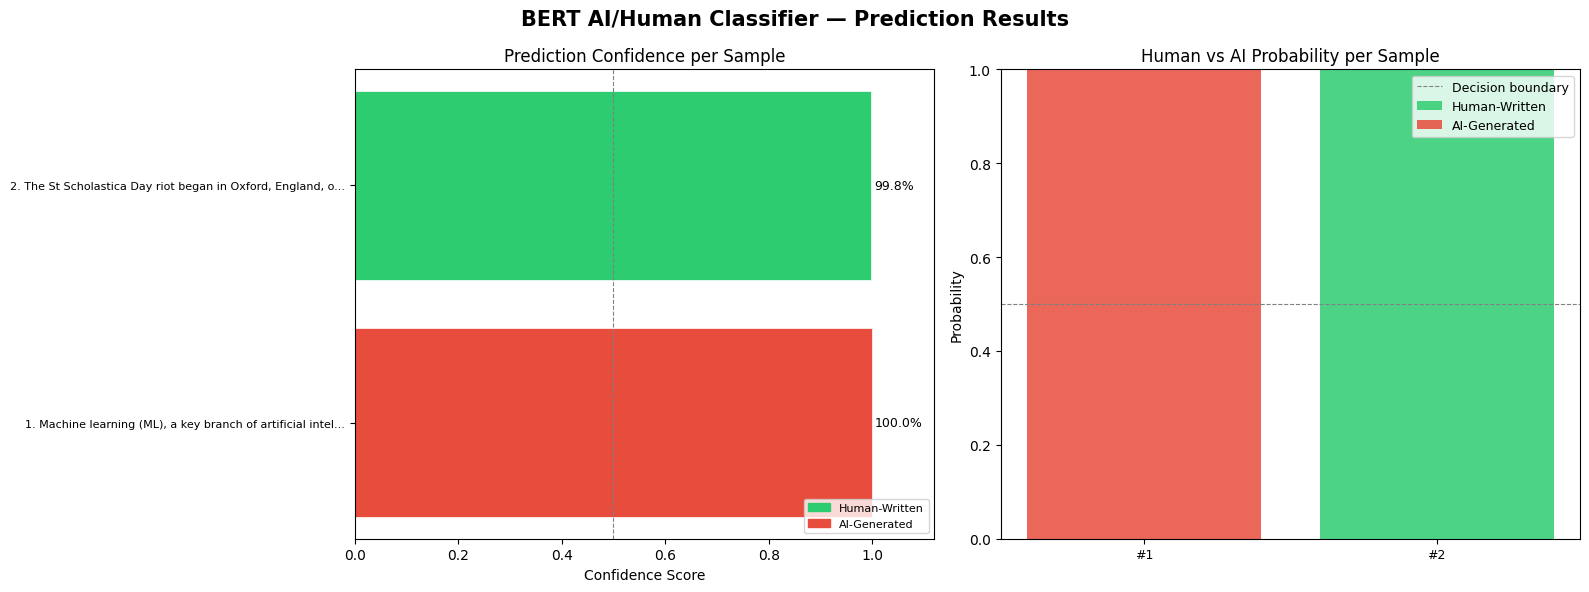

In [26]:
# Collect raw prediction data for plotting
plot_data = []
for text in test_texts:
    res = predict(text, verbose=False)
    plot_data.append({
        'text_snippet': text[:55] + '...',
        'label'       : res['label'],
        'confidence'  : res['confidence'],
        'human_prob'  : res['probs']['Human-Written'],
        'ai_prob'     : res['probs']['AI-Generated']
    })

plot_df = pd.DataFrame(plot_data)

# ─── Plot 1: Confidence bar chart ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('BERT AI/Human Classifier — Prediction Results', fontsize=15, fontweight='bold')

# Color bars by predicted label
colors = [LABEL_COLORS[lbl] for lbl in plot_df['label']]
bars = axes[0].barh(
    range(len(plot_df)),
    plot_df['confidence'],
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

# Annotate bars with confidence %
for i, (conf, lbl) in enumerate(zip(plot_df['confidence'], plot_df['label'])):
    axes[0].text(conf + 0.005, i, f"{conf:.1%}", va='center', fontsize=9)

axes[0].set_yticks(range(len(plot_df)))
axes[0].set_yticklabels([f"{i+1}. {s}" for i, s in enumerate(plot_df['text_snippet'])], fontsize=8)
axes[0].set_xlabel('Confidence Score')
axes[0].set_title('Prediction Confidence per Sample')
axes[0].set_xlim(0, 1.12)
axes[0].axvline(x=0.5, color='gray', linestyle='--', linewidth=0.8, label='Decision boundary (0.5)')
axes[0].legend(handles=[
    mpatches.Patch(color='#2ecc71', label='Human-Written'),
    mpatches.Patch(color='#e74c3c', label='AI-Generated')
], loc='lower right', fontsize=8)

# ─── Plot 2: Probability comparison (stacked) ─────────────────────────────────
x = range(len(plot_df))
axes[1].bar(x, plot_df['human_prob'], label='Human-Written', color='#2ecc71', alpha=0.85)
axes[1].bar(x, plot_df['ai_prob'],   label='AI-Generated',  color='#e74c3c', alpha=0.85,
            bottom=plot_df['human_prob'])  # stacked

axes[1].axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, label='Decision boundary')
axes[1].set_xticks(range(len(plot_df)))
axes[1].set_xticklabels([f"#{i+1}" for i in range(len(plot_df))], fontsize=9)
axes[1].set_ylabel('Probability')
axes[1].set_title('Human vs AI Probability per Sample')
axes[1].set_ylim(0, 1.0)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('prediction_visualization.png', dpi=150, bbox_inches='tight')
plt.show()